# US Car Accidents - Severity Prediction
## Celeste De Bernardinis

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, r2_score, f1_score, accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, auc, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.impute import SimpleImputer

In [69]:
df = pd.read_parquet("US_accidents_dataset_subsample.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     1000000 non-null  object 
 1   Source                 1000000 non-null  object 
 2   Severity               1000000 non-null  int64  
 3   Start_Time             1000000 non-null  object 
 4   End_Time               1000000 non-null  object 
 5   Start_Lat              1000000 non-null  float64
 6   Start_Lng              1000000 non-null  float64
 7   End_Lat                560113 non-null   object 
 8   End_Lng                560113 non-null   object 
 9   Distance(mi)           1000000 non-null  float64
 10  Description            1000000 non-null  object 
 11  Street                 998585 non-null   object 
 12  City                   999963 non-null   object 
 13  County                 1000000 non-null  object 
 14  State              

## Considerations:
* For End_Lat and End_Ltg we have almost 50% of missing values
* Heterogeneous data, but the majority of features are categorical

In [5]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,None,None,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
1,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,None,None,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
2,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,None,None,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day
3,A-7,Source2,2,2016-02-08 07:59:35,2016-02-08 08:29:35,39.758274,-84.230507,None,None,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-15,Source2,2,2016-02-08 08:39:43,2016-02-08 09:09:43,39.972038,-82.913521,None,None,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [130]:
df.describe()

,Severity,Start_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),...,Wind_Speed(mph),Precipitation(in),start_hour,start_weekday,is_weekend,is_night,is_rush_hour,bad_weather,bad_weather_night,rush_hour_rain
count,1000000.000000,903785,1000000.000000,1000000.000000,560113.000000,560113.000000,1000000.000000,978823.000000,741189.000000,977452.000000,...,925942.000000,715098.000000,903785.000000,903785.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2.212410,2020-03-22 02:36:39.526204416,36.201785,-94.685380,36.259611,-95.703696,0.561912,61.683230,58.287491,64.836068,...,7.688670,0.008416,12.268307,2.569984,0.138585,0.145359,0.369220,0.177167,0.024300,0.024582
min,1.000000,2016-02-08 06:07:59,24.566999,-124.497420,24.569978,-124.497419,0.000000,-89.000000,-89.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2018-09-17 07:46:09,33.398775,-117.214386,33.461899,-117.745151,0.000000,49.000000,43.000000,48.000000,...,4.600000,0.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2020-06-24 12:46:13,35.825378,-87.758950,36.177925,-88.026877,0.030000,64.000000,62.000000,67.000000,...,7.000000,0.000000,13.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,2021-10-28 13:46:36,40.090187,-80.353260,40.181998,-80.248396,0.462000,76.000000,75.000000,84.000000,...,10.400000,0.000000,17.000000,4.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,4.000000,2023-03-31 22:46:43,49.000504,-67.484130,49.000769,-67.484130,242.339996,162.000000,162.000000,100.000000,...,822.800000,10.110000,23.000000,6.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,0.487631,NaN,5.076235,17.383016,5.271133,18.093478,1.811210,19.002175,22.367036,22.806359,...,5.436819,0.105850,5.453018,1.797436,0.345513,0.352463,0.482594,0.381810,0.153979,0.154848


Accident severity is difficult to predict using only contextual variables available before the event. Most predictive power in the dataset is contained in post-event descriptions, which are not usable in a proactive setting.

Without "Description" the performance is poor => Feature engineering: features were selected to reflect only information available prior to or at the time of the accident, excluding post-event variables and textual descriptions to avoid data leakage.

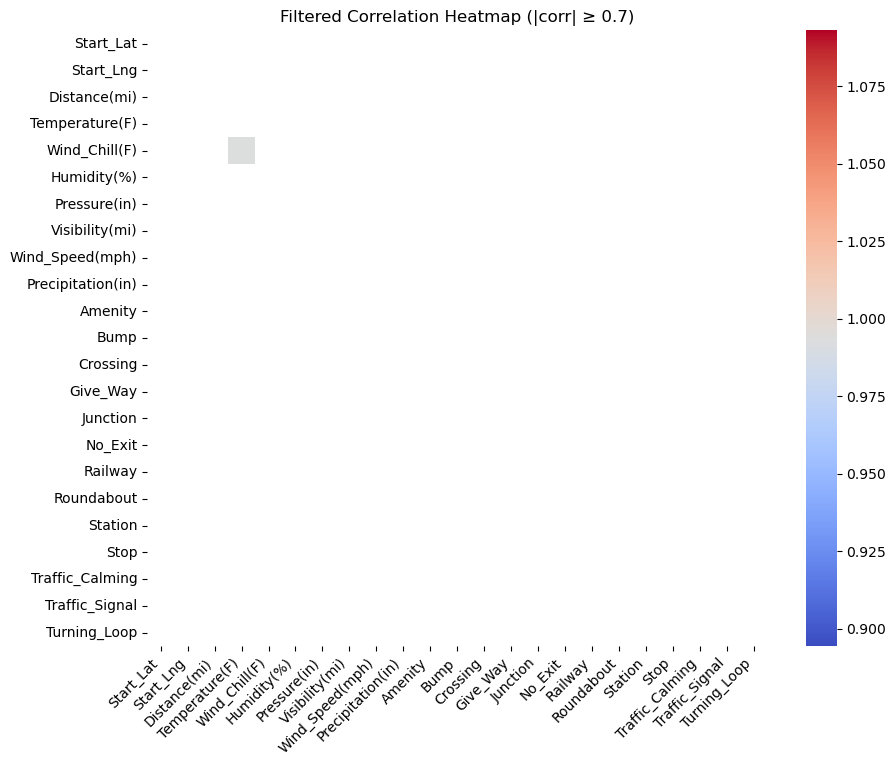

In [3]:
int_features = df.select_dtypes(include=['float64', 'bool'])

corr_matrix = int_features.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

corr_filtered = corr_matrix.copy()
corr_filtered[np.abs(corr_filtered) < 0.7] = np.nan

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_filtered, mask=mask, cmap='coolwarm', annot=False)
plt.title("Filtered Correlation Heatmap (|corr| ≥ 0.7)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

Windchill has significantly more missing values than Temperature. Since the two variables are highly correlated, we may consider keeping only Temperature to avoid redundancy and data loss.

In [15]:
# Comparison 
df[['Weather_Timestamp','Start_Time']].head(10) # Weather_Timestamp was excluded:
# potentially introducing redundancy with Start_Time

,Weather_Timestamp,Start_Time
0,2016-02-08 05:51:00,2016-02-08 06:07:59
1,2016-02-08 07:38:00,2016-02-08 07:23:34
2,2016-02-08 07:53:00,2016-02-08 07:39:07
3,2016-02-08 07:56:00,2016-02-08 07:59:35
4,2016-02-08 08:28:00,2016-02-08 08:39:43
5,2016-02-08 08:58:00,2016-02-08 08:53:17
6,2016-02-08 09:56:00,2016-02-08 10:24:27
7,2016-02-08 11:53:00,2016-02-08 11:53:19
8,2016-02-08 13:56:00,2016-02-08 14:24:48
9,2016-02-08 14:56:00,2016-02-08 14:56:57


In [70]:
# Converting objects into numeric type for numerical variables with missing values
df["End_Lat"] = pd.to_numeric(df["End_Lat"], errors="coerce") # Not valid values => becoming NaN
df["End_Lng"] = pd.to_numeric(df["End_Lng"], errors="coerce")

# Converting in date time
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

# Temporal features were extracted from the original Start timestamps, to capture temporal patterns in accident severity
df["start_hour"] = df["Start_Time"].dt.hour
df["start_weekday"] = df["Start_Time"].dt.weekday

df['is_weekend'] = df['start_weekday'].isin([5,6]).astype(int)
df['is_night'] = ((df['start_hour'] < 6) | (df['start_hour'] > 20)).astype(int)
df['is_rush_hour'] = df['start_hour'].isin([7,8,9,16,17,18]).astype(int)

df['bad_weather'] = (
    (df['Precipitation(in)'] > 0) |
    (df['Visibility(mi)'] < 5) |
    (df['Wind_Speed(mph)'] > 15)
).astype(int)

#Interactions
df['bad_weather_night'] = df['bad_weather'] * df['is_night']
df['rush_hour_rain'] = df['is_rush_hour'] * (df['Precipitation(in)'] > 0)

- Light condition variables substituted  by 'is_night';
- Weather condition (too many categories) substituted  by 'bad_weather';
- Wind direction redundant;
- Number, Side, Airport_Code, TimeZone, ZipCode poorly informative;
- No_Exit, Railway redundant;
- Weather_Timestamp was excluded: potentially introducing redundancy with Start_Time

In [71]:
# The type of street is important:
def road_type(street):
    street = str(street).lower()
    if 'i-' in street or 'fwy' in street or 'highway' in street:
        return 'highway'
    elif 'ave' in street or 'st' in street or 'blvd' in street or 'road' in street:
        return 'urban'
    else:
        return 'other'

df['road_type'] = df['Street'].apply(road_type)

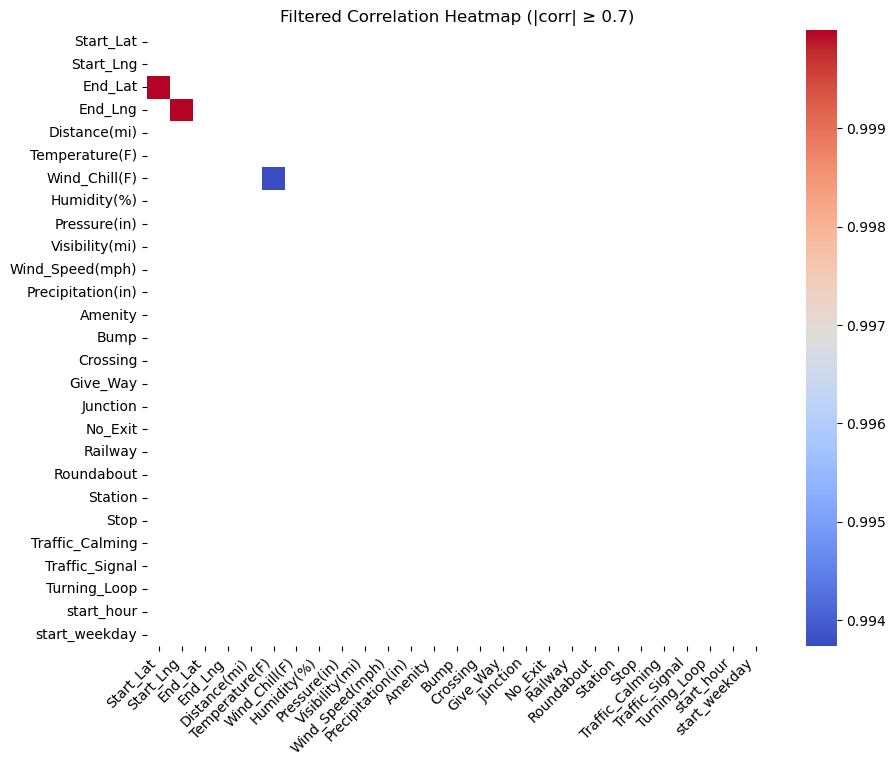

In [6]:
int_features = df.select_dtypes(include=['float64', 'bool'])

corr_matrix = int_features.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

corr_filtered = corr_matrix.copy()
corr_filtered[np.abs(corr_filtered) < 0.7] = np.nan

# plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_filtered, mask=mask, cmap='coolwarm', annot=False)
plt.title("Filtered Correlation Heatmap (|corr| ≥ 0.7)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [72]:
num_features = [
    'Distance(mi)',
    'Temperature(F)',
    'Visibility(mi)',
    'Humidity(%)',
    'Pressure(in)',
    'Precipitation(in)',
    'Wind_Speed(mph)',
    'start_hour',
    'start_weekday'
] 

bool_features = [
    'is_weekend',
    'is_night',
    'is_rush_hour',
    'bad_weather',
    'bad_weather_night',
    'rush_hour_rain',
    'Amenity', 
    'Bump',
    'Traffic_Signal',
    'Junction',
    'Crossing',
    'Stop',
    'Turning_Loop',
    'Traffic_Calming',
    'Roundabout',
    'Station',
    'Give_Way'
]

cat_features = [
    'Country',
    'Street',
    'State',
    'City',
    'County',
    'road_type'
]

In [73]:
# Categorical variables with missing values have to be converted into strings for Catboost
for col in cat_features:
    df[col] = df[col].astype(str)

# Categorical features with extremely high cardinality may lead to overfitting and reduced generalization  
for col in cat_features:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique values") # Remove them or treat them as text variables

cat_features.remove("Country") # only 1 value
cat_features.remove("Street") # too many values
cat_features.remove("City") # too many values
print(df['Description']) #probably is data leakage! (When included in the model, it accounts for 56% of the importance)

features = num_features + bool_features + cat_features
target = 'Severity'

Country: 1 unique values
Street: 129991 unique values
State: 49 unique values
City: 10755 unique values
County: 1703 unique values
road_type: 3 unique values
0         Accident on Brice Rd at Tussing Rd. Expect del...
1         Accident on I-75 Southbound at Exits 52 52B US...
2         Accident on McEwen Rd at OH-725 Miamisburg Cen...
3         Accident on Oakridge Dr at Woodward Ave. Expec...
4         Accident on OH-16 Broad St at James Rd. Expect...
                                ...                        
999995    At Gaviota Roadside Rest Area - Accident. Lane...
999996    At Diamond Bar Blvd - Accident. in the left lane.
999997               At I-10/San Bernardino Fwy - Accident.
999998       At CA-2/Santa Monica Blvd/Exit 55A - Accident.
999999                            At Tustin Ave - Accident.
Name: Description, Length: 1000000, dtype: object


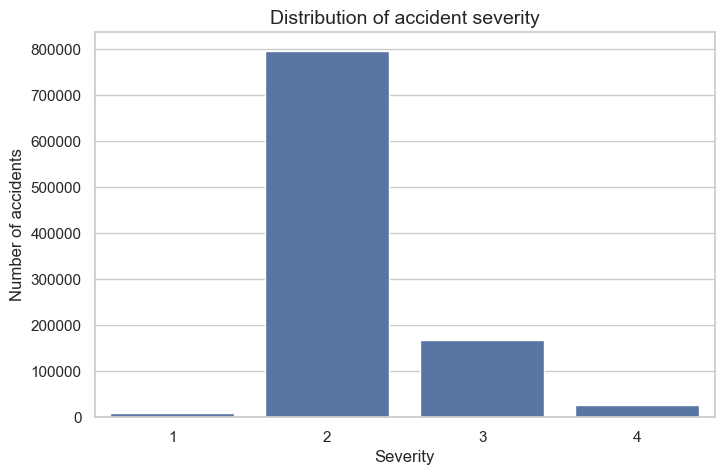

In [22]:
# Target distribution
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))
sns.countplot(x='Severity', data=df)
plt.title("Distribution of accident severity", fontsize=14)
plt.xlabel("Severity", fontsize=12)
plt.ylabel("Number of accidents", fontsize=12)
plt.show()

In [29]:
df['Severity'].value_counts()
df['Severity'].value_counts(normalize=True) * 100 #percentage

Severity
2    79.6661
3    16.8093
4     2.6521
1     0.8725
Name: proportion, dtype: float64

Imbalanced dataset!

In [74]:
# Train/test split
target = 'Severity'
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[target]
) #stratify => maintains the class ratios in the train/test split

# Adding Geo Cluster 
coords = train_df[['Start_Lat', 'Start_Lng']]
kmeans = KMeans(n_clusters=20, random_state=0).fit(coords)
kmeans.fit(train_df[['Start_Lat','Start_Lng']])
train_df['geo_cluster'] = kmeans.predict(train_df[['Start_Lat','Start_Lng']])
test_df['geo_cluster'] = kmeans.predict(test_df[['Start_Lat','Start_Lng']])
cat_features.append("geo_cluster")
features = num_features + bool_features + cat_features

train_pool = Pool(
    data=train_df[features],
    label=train_df[target],
    cat_features=cat_features
)

test_pool = Pool(
    data=test_df[features],
    label=test_df[target],
    cat_features=cat_features
)

# Introducing class weights given the imbalanced dataset (computing on training set)
target_counts = train_df['Severity'].value_counts()
num_classes = len(target_counts)
total = len(train_df)
class_weights = {cls: total/(num_classes*count) for cls, count in target_counts.items()} # Inverse class frequency formula
print(class_weights)

{2: 0.3138096650238731, 3: 1.4872763508187457, 4: 9.426403355799595, 1: 28.653295128939828}


## CatBoost Multiclassifier
It treats the categories as independent and unordered, but implementing the ordinal version would require building k models, and with as much data as there is in this case, that is unfeasible.

reference: https://python.plainenglish.io/the-use-of-catboost-in-solving-an-ordinal-classification-problem-866bf5aae943

In [75]:
# CatBoost model 
model = CatBoostClassifier(
    iterations=1000,          
    learning_rate=0.05, 
    depth=6, 
    loss_function='MultiClass', 
    eval_metric='MultiClass',
    random_seed=42,
    class_weights=class_weights, 
    early_stopping_rounds=50, 
    verbose=100
)
 
model.fit(train_pool, eval_set=test_pool) 

0:	learn: 1.3380666	test: 1.3380613	best: 1.3380613 (0)	total: 9.56s	remaining: 2h 39m 13s
100:	learn: 0.7655157	test: 0.7720738	best: 0.7720738 (100)	total: 14m 27s	remaining: 2h 8m 38s
200:	learn: 0.7219038	test: 0.7324678	best: 0.7324678 (200)	total: 31m 21s	remaining: 2h 4m 40s
300:	learn: 0.6965525	test: 0.7115266	best: 0.7115266 (300)	total: 54m 49s	remaining: 2h 7m 19s
400:	learn: 0.6786994	test: 0.6985276	best: 0.6985276 (400)	total: 1h 15m 20s	remaining: 1h 52m 32s
500:	learn: 0.6662218	test: 0.6910847	best: 0.6910847 (500)	total: 1h 32m 22s	remaining: 1h 31m 59s
600:	learn: 0.6563850	test: 0.6859181	best: 0.6859181 (600)	total: 1h 48m 40s	remaining: 1h 12m 8s
700:	learn: 0.6474554	test: 0.6820105	best: 0.6820105 (700)	total: 2h 9m 16s	remaining: 55m 8s
800:	learn: 0.6402039	test: 0.6791215	best: 0.6791215 (800)	total: 2h 29m 14s	remaining: 37m 4s
900:	learn: 0.6328250	test: 0.6759851	best: 0.6759691 (899)	total: 2h 45m 5s	remaining: 18m 8s
999:	learn: 0.6265857	test: 0.673610

CatBoostClassifier(class_weights={2: 0.3138096650238731, 3: 1.4872763508187457, 4: 9.426403355799595, 1: 28.653295128939828}, depth=6, early_stopping_rounds=50, eval_metric='MultiClass', iterations=1000, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [76]:
# Prediction on test set
y_pred_class = model.predict(test_pool)
y_pred_class = y_pred_class.flatten() 
# Probabilities
y_pred_proba = model.predict_proba(test_pool)  # array NxK

# Model evaluation:

# F1 macro
f1_class = f1_score(test_df[target], y_pred_class, average='macro')
print(f"F1 Macro: {f1_class:.4f}")

# Accuracy
acc_class = accuracy_score(test_df[target], y_pred_class)
print(f"Accuracy: {acc_class:.4f}")

mae_class = mean_absolute_error(test_df[target], y_pred_class)
print(f"MAE: {mae_class:.4f}")

print("Classification report:\n")
print(classification_report(test_df[target], y_pred_class, digits=4))

F1 Macro: 0.4178
Accuracy: 0.6149
MAE: 0.5354
Classification report:

              precision    recall  f1-score   support

           1     0.0620    0.8527    0.1156      1745
           2     0.9576    0.5835    0.7251    159332
           3     0.5434    0.7270    0.6219     33619
           4     0.1205    0.7707    0.2084      5304

    accuracy                         0.6149    200000
   macro avg     0.4209    0.7335    0.4178    200000
weighted avg     0.8579    0.6149    0.6888    200000



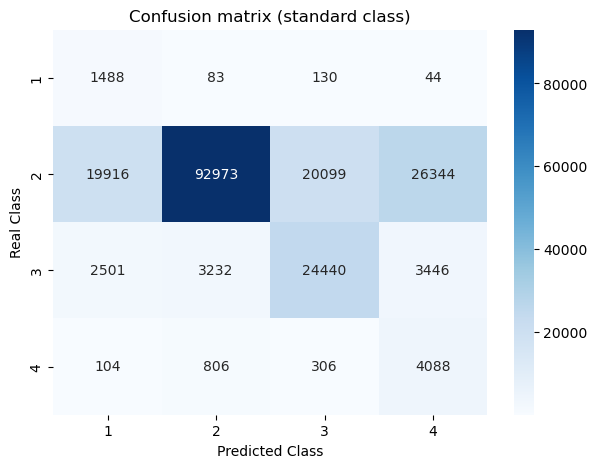

In [77]:
# Confusion matrix 
cm = confusion_matrix(test_df[target], y_pred_class)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel("Predicted Class")
plt.ylabel("Real Class")
plt.title("Confusion matrix (standard class)")
plt.show()

Errors distribution:

In [78]:
errors_multiclass = abs(test_df[target] -  y_pred_class)
print(pd.Series(errors_multiclass).value_counts().sort_index())

Severity
0    122989
1     47082
2     29781
3       148
Name: count, dtype: int64


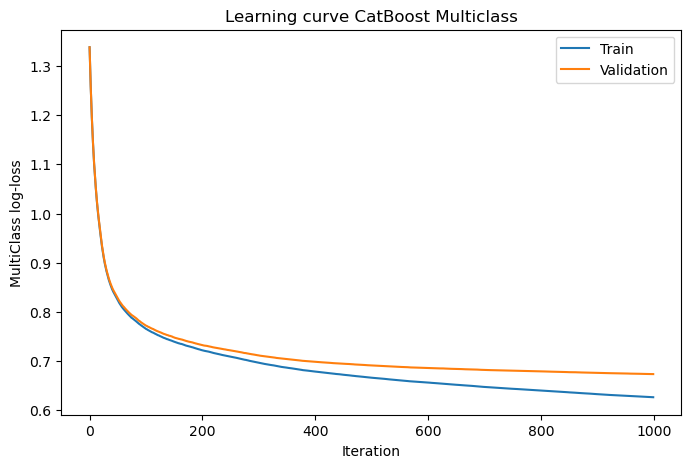

In [79]:
# learning curve 
results = model.get_evals_result()
plt.figure(figsize=(8,5))
plt.plot(results['learn']['MultiClass'], label='Train')
plt.plot(results['validation']['MultiClass'], label='Validation')
plt.xlabel("Iteration")
plt.ylabel("MultiClass log-loss")
plt.legend()
plt.title("Learning curve CatBoost Multiclass")
plt.show()

Although CatBoost reports the best iteration at 999, most of the performance gain is achieved around iteration 200, indicating diminishing returns beyond this point. For computational efficiency, the model can be truncated at the elbow without meaningful loss of accuracy.

### Feature importance

In [80]:
importances_class = model.get_feature_importance()
df_imp = pd.DataFrame({
    'feature': train_df[features].columns,
    'importance': importances_class
})

df_imp = df_imp.sort_values(by='importance', ascending=False)
print(df_imp)

              feature  importance
0        Distance(mi)   29.461889
27             County    9.275721
5   Precipitation(in)    8.866870
26              State    7.909590
7          start_hour    6.936966
29        geo_cluster    6.477880
1      Temperature(F)    5.970221
28          road_type    5.386489
4        Pressure(in)    4.846076
8       start_weekday    3.673955
6     Wind_Speed(mph)    2.484364
3         Humidity(%)    2.278139
17     Traffic_Signal    1.231577
10           is_night    0.933031
2      Visibility(mi)    0.854167
18           Junction    0.671385
9          is_weekend    0.660664
19           Crossing    0.559473
11       is_rush_hour    0.524145
20               Stop    0.363184
24            Station    0.224960
14     rush_hour_rain    0.108605
12        bad_weather    0.093102
15            Amenity    0.081627
13  bad_weather_night    0.041531
16               Bump    0.036071
25           Give_Way    0.032649
22    Traffic_Calming    0.015669
21       Turni

## CatBoost Regression

In [81]:
model_reg = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)
                    
sample_weights = train_df[target].map(class_weights) #handling imbalanced dataset

train_pool_reg = Pool(
    data=train_df[features], 
    label=train_df[target], 
    cat_features=cat_features,
    weight=sample_weights
)

test_pool_reg = Pool(
    data=test_df[features],
    label=test_df[target],
    cat_features=cat_features
)

model_reg.fit(train_pool_reg, eval_set=test_pool_reg)
y_pred_reg_cont = model_reg.predict(test_pool_reg)

#rounding
y_pred_reg = np.clip(np.round(y_pred_reg_cont), 1, 4).astype(int)

#evaluation
mae = mean_absolute_error(test_df[target], y_pred_reg)
print(f"MAE - Regressor: {mae:.4f}")
f1_reg = f1_score(test_df[target], y_pred_reg, average='macro')
acc_reg = accuracy_score(test_df[target], y_pred_reg)
print(f"F1 Macro - Regressor: {f1_reg:.4f}")
print(f"Accuracy - Regressor: {acc_reg:.4f}")

0:	learn: 1.0929224	test: 0.5646884	best: 0.5646884 (0)	total: 1.36s	remaining: 22m 36s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5646883934
bestIteration = 0

Shrink model to first 1 iterations.
MAE - Regressor: 0.5145
F1 Macro - Regressor: 0.2257
Accuracy - Regressor: 0.4885


In [82]:
# Distribuzione errori
errors = abs(test_df[target] - y_pred_reg)
error_dist = pd.Series(errors).value_counts().sort_index()
print("\nDistribuzione errori:")
print(error_dist)


Distribuzione errori:
Severity
0     97705
1    101691
2       604
Name: count, dtype: int64


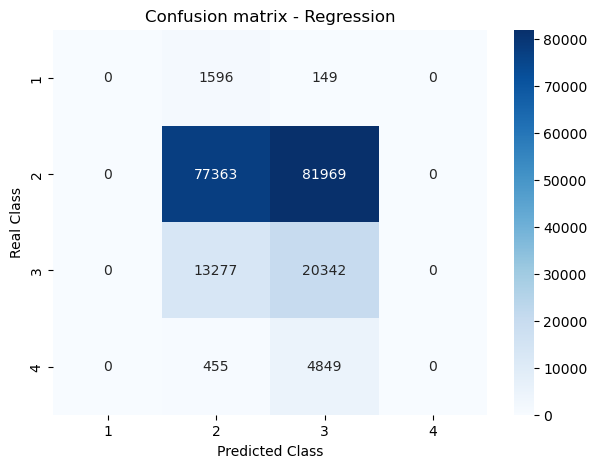

In [83]:
# Confusion matrix - Regression
cm = confusion_matrix(test_df[target], y_pred_reg)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel("Predicted Class")
plt.ylabel("Real Class")
plt.title("Confusion matrix - Regression")
plt.show()

NONE OF THE PREDICTED OBSERVATIONS FOR CLASSES 1 AND 4!!

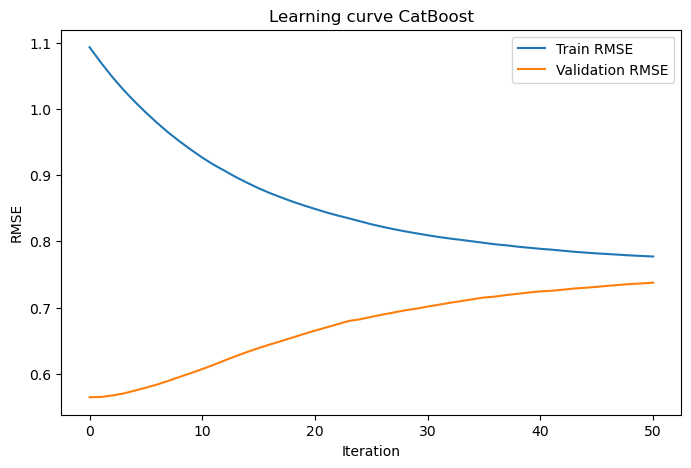

In [84]:
# learning curve 
results = model_reg.get_evals_result()
plt.figure(figsize=(8,5))
plt.plot(results['learn']['RMSE'], label='Train RMSE')
plt.plot(results['validation']['RMSE'], label='Validation RMSE')
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.legend()
plt.title("Learning curve CatBoost")
plt.show()

The regression model quickly converged to a near-constant solution, with no improvement beyond the first iterations, indicating a lack of predictive signal for continuous modeling and confirming the inadequacy of regression for this task.

### Feature importance

In [85]:
importances_reg = model_reg.get_feature_importance()
df_imp_reg = pd.DataFrame({
    'feature': train_df[features].columns,
    'importance': importances_reg
})

df_imp_reg = df_imp_reg.sort_values(by='importance', ascending=False)
print(df_imp_reg)

              feature  importance
0        Distance(mi)   57.927650
5   Precipitation(in)   15.576996
26              State   14.834317
28          road_type    9.875111
7          start_hour    1.785926
1      Temperature(F)    0.000000
4        Pressure(in)    0.000000
6     Wind_Speed(mph)    0.000000
8       start_weekday    0.000000
9          is_weekend    0.000000
10           is_night    0.000000
11       is_rush_hour    0.000000
3         Humidity(%)    0.000000
2      Visibility(mi)    0.000000
13  bad_weather_night    0.000000
12        bad_weather    0.000000
14     rush_hour_rain    0.000000
15            Amenity    0.000000
18           Junction    0.000000
19           Crossing    0.000000
16               Bump    0.000000
17     Traffic_Signal    0.000000
21       Turning_Loop    0.000000
20               Stop    0.000000
22    Traffic_Calming    0.000000
23         Roundabout    0.000000
25           Give_Way    0.000000
24            Station    0.000000
27            

## Comparison

In [86]:
metrics = {
    'Metric': ['Accuracy', 'F1-score', 'MAE'],
    'Classification': [acc_class, f1_class, mae_class],
    'Regression': [acc_reg, f1_reg, mae]
}

df_metrics = pd.DataFrame(metrics)

print(df_metrics)

     Metric  Classification  Regression
0  Accuracy        0.614945    0.488525
1  F1-score        0.417766    0.225656
2       MAE        0.535440    0.514495


Both models perform poorly. The regression model doesn't predict accidents 1 and 4 (extreme categories), despite the weights assigned to rare classes.

- CatBoost regressor: not suitable => ignores extreme categories
- CatBoost multiclass: better, but => struggles with rare classes and computationally expensive

# Anomaly detection: class 4 (max severity) vs others

### Isolation forest

In [88]:
train_encoded = train_df.copy(deep=True)
test_encoded = test_df.copy(deep=True)

## Missing values
train_encoded['start_weekday'] = train_encoded['start_weekday'].fillna(-1)
test_encoded['start_weekday'] = test_encoded['start_weekday'].fillna(-1)
train_encoded['start_hour'] = train_encoded['start_hour'].fillna(-1)
test_encoded['start_hour'] = test_encoded['start_hour'].fillna(-1)
train_encoded['Temperature(F)'] = train_encoded['Temperature(F)'].fillna(train_encoded['Temperature(F)'].median()) 
test_encoded['Temperature(F)'] = test_encoded['Temperature(F)'].fillna(test_encoded['Temperature(F)'].median()) 
train_encoded['Visibility(mi)'] = train_encoded['Visibility(mi)'].fillna(train_encoded['Visibility(mi)'].median()) 
test_encoded['Visibility(mi)'] = test_encoded['Visibility(mi)'].fillna(test_encoded['Visibility(mi)'].median()) 
train_encoded['Visibility(mi)'] = train_encoded['Visibility(mi)'].fillna(train_encoded['Visibility(mi)'].median()) 
test_encoded['Visibility(mi)'] = test_encoded['Visibility(mi)'].fillna(test_encoded['Visibility(mi)'].median()) 
train_encoded['Wind_Speed(mph)'] = train_encoded['Wind_Speed(mph)'].fillna(train_encoded['Wind_Speed(mph)'].median()) 
test_encoded['Wind_Speed(mph)'] = test_encoded['Wind_Speed(mph)'].fillna(test_encoded['Wind_Speed(mph)'].median()) 
train_encoded['Precipitation(in)'] = train_encoded['Precipitation(in)'].fillna(train_encoded['Precipitation(in)'].median()) 
test_encoded['Precipitation(in)'] = test_encoded['Precipitation(in)'].fillna(test_encoded['Precipitation(in)'].median())
train_encoded['Pressure(in)'] = train_encoded['Pressure(in)'].fillna(train_encoded['Pressure(in)'].median()) 
test_encoded['Pressure(in)'] = test_encoded['Pressure(in)'].fillna(test_encoded['Pressure(in)'].median())
train_encoded['Humidity(%)'] = train_encoded['Humidity(%)'].fillna(train_encoded['Humidity(%)'].median()) 
test_encoded['Humidity(%))'] = test_encoded['Humidity(%)'].fillna(test_encoded['Humidity(%)'].median())
      
# Encode categorical features
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

train_encoded[cat_features] = encoder.fit_transform(train_encoded[cat_features])
test_encoded[cat_features] = encoder.transform(test_encoded[cat_features])

for col in bool_features:
    train_encoded[col] = train_encoded[col].astype(int)
    test_encoded[col] = test_encoded[col].astype(int)
    
#handling outliers
train_encoded['Distance(mi)'] = np.log1p(train_encoded['Distance(mi)'])
test_encoded['Distance(mi)'] = np.log1p(test_encoded['Distance(mi)'])
train_encoded['Wind_Speed(mph)'] = np.clip(train_encoded['Wind_Speed(mph)'], 0, 50)
test_encoded['Wind_Speed(mph)'] = np.clip(test_encoded['Wind_Speed(mph)'], 0, 50)
    
# Standardize numerical features
scaler = RobustScaler()

train_encoded[num_features] = scaler.fit_transform(train_encoded[num_features])
test_encoded[num_features] = scaler.transform(test_encoded[num_features])

X_train = train_encoded[features]   # features = num_features + bool_features + cat_features
X_test = test_encoded[features]

y_train = (train_encoded['Severity'] == 4).astype(int)  # 1 = rare class
y_test = (test_encoded['Severity'] == 4).astype(int)

In [89]:
X_train.describe()

,Distance(mi),Temperature(F),Visibility(mi),Humidity(%),Pressure(in),Precipitation(in),Wind_Speed(mph),start_hour,start_weekday,is_weekend,...,Stop,Turning_Loop,Traffic_Calming,Roundabout,Station,Give_Way,State,County,road_type,geo_cluster
count,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,...,800000.000000,800000.0,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000,800000.000000
mean,0.646753,-0.086950,-0.886553,-0.060354,-0.482183,0.005999,0.126990,-0.001376,0.075228,0.138379,...,0.027860,0.0,0.000989,0.000032,0.026091,0.004671,20.045870,881.317785,0.933335,9.103103
std,1.227623,0.722818,2.648629,0.644072,1.528632,0.088775,1.012803,0.721587,0.668971,0.345297,...,0.164572,0.0,0.031429,0.005701,0.159407,0.068187,15.329559,423.252544,0.768700,5.343010
min,-0.077547,-5.884615,-10.000000,-1.885714,-41.338462,0.000000,-1.400000,-1.333333,-1.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.077547,-0.538462,0.000000,-0.514286,-0.738462,0.000000,-0.400000,-0.444444,-0.333333,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,3.000000,552.000000,0.000000,5.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,18.000000,899.000000,1.000000,9.000000
75%,0.922453,0.461538,0.000000,0.485714,0.261538,0.000000,0.600000,0.555556,0.666667,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,36.000000,1224.000000,2.000000,14.000000
max,14.337084,3.769231,90.000000,0.942857,44.261538,10.110000,8.600000,1.333333,1.333333,1.000000,...,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,48.000000,1672.000000,2.000000,19.000000


C:\Users\CELESTE\anaconda64\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\CELESTE\anaconda64\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


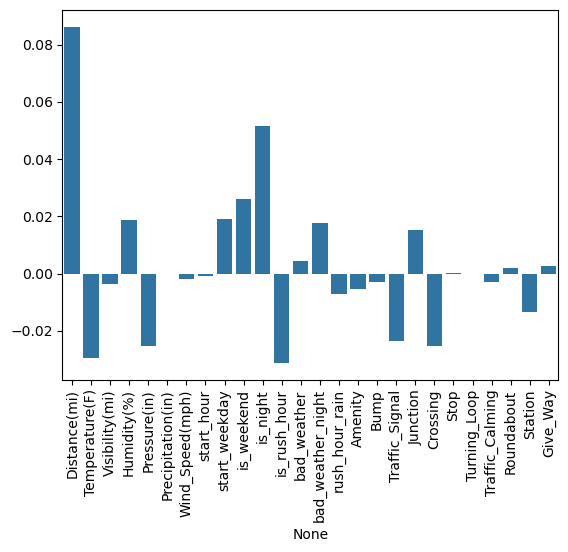

In [87]:
# Correlation with the Target variable "Accident=4"
ty = (train_df['Severity'] == 4).astype(int)
corr = train_df[num_features + bool_features].corrwith(ty)
sns.barplot(x=corr.index, y=corr.values)
plt.xticks(rotation=90)
plt.show()

It confirms the feature importance analyzed by CatBoost models. We can remove some less important features to see if the anomaly detection gets better.

In [90]:
print(f"Number of original features: {len(features)}")

threshold = 0.01  
selected_features = corr[abs(corr) >= threshold].index.tolist()

print("Feature selezionate (corr >= {}):".format(threshold))
print(selected_features)

X_train = train_encoded[selected_features]
X_test = test_encoded[selected_features]

print(f"Number of selected features: {len(selected_features)}")

Number of original features: 30
Feature selezionate (corr >= 0.01):
['Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'start_weekday', 'is_weekend', 'is_night', 'is_rush_hour', 'bad_weather_night', 'Traffic_Signal', 'Junction', 'Crossing', 'Station']
Number of selected features: 13


In [91]:
# % anomalies 
n_anomalies = (df['Severity'] == 4).sum()
n_total = len(df)
contamination = n_anomalies / n_total

print(f"Contamination (fraction of anomalies): {contamination:.4f}")

Contamination (fraction of anomalies): 0.0265


In [36]:
X_train_norm = X_train[train_df['Severity'] != 4]

iso = IsolationForest(
    n_estimators=200,          # trees
    contamination=contamination,        # anomalies % (tune!) => we are fitting on the NORMAL training set
    max_samples=100000,        # subsampling (speed)
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train_norm)

,n_estimators,200
,max_samples,100000
,contamination,np.float64(0.026521)
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [37]:
y_pred = iso.predict(X_test)
y_pred_binary = (y_pred == -1).astype(int)

#Evaluation
print(confusion_matrix(y_test, y_pred_binary))
print(classification_report(y_test, y_pred_binary))

[[947512  25967]
 [ 24882   1639]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97    973479
           1       0.06      0.06      0.06     26521

    accuracy                           0.95   1000000
   macro avg       0.52      0.52      0.52   1000000
weighted avg       0.95      0.95      0.95   1000000



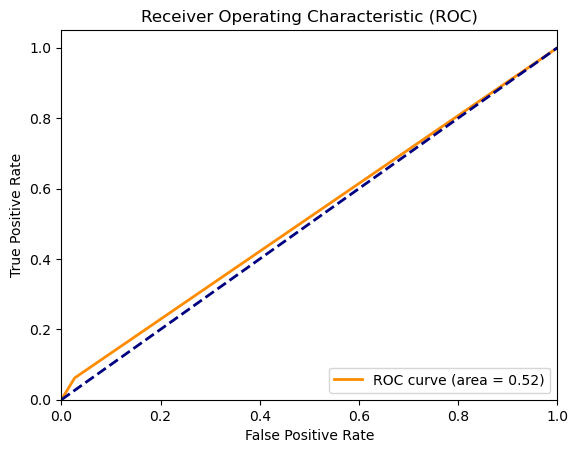

In [38]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_binary)

roc_auc = auc(fpr, tpr)

# ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## Autoencoders

In [92]:
X_train_full = train_encoded[selected_features]
X_test_full = test_encoded[selected_features]

X_train = X_train_full[y_train == 0]  # solo normali

input_dim = X_train.shape[1]
encoding_dim = 4
hidden_dim = 8

input_layer = Input(shape=(input_dim,))
hidden_layer_1 = Dense(hidden_dim, activation='relu')(input_layer)
encoded_layer = Dense(encoding_dim, activation='relu')(hidden_layer_1)
hidden_layer_2 = Dense(hidden_dim, activation='relu')(encoded_layer)
output_layer = Dense(input_dim)(hidden_layer_2)

autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
autoencoder.fit(X_train, X_train, 
                epochs=100, 
                batch_size=256, 
                validation_split=0.2, 
                callbacks=[early_stopping],
                verbose=1)

# reconstruction errors
recon_train = np.mean(np.power(X_train - autoencoder.predict(X_train), 2), axis=1)
recon_test = np.mean(np.power(X_test_full - autoencoder.predict(X_test_full), 2), axis=1)

percentili = np.linspace(90, 99.5, 20)  # range percentili possibili
best_f1 = 0
best_threshold = None

for p in percentili:
    thresh = np.percentile(recon_train, p)
    y_pred = (recon_test > thresh).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"Threshold ottimale: {best_threshold:.4f}, F1 sulla classe rara: {best_f1:.4f}")

y_pred_final = (recon_test > best_threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, digits=3))

Epoch 1/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.1142 - val_loss: 0.0803
Epoch 2/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 0.0807 - val_loss: 0.0801
Epoch 3/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0804 - val_loss: 0.0799
Epoch 4/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0800 - val_loss: 0.0797
Epoch 5/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0796 - val_loss: 0.0795
Epoch 6/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0795 - val_loss: 0.0794
Epoch 7/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.0795 - val_loss: 0.0794
Epoch 8/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0794 - val_loss: 0.0794
Epoch 9/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 0.0794 - val_loss: 0.0794
Epoch 10/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.0794 - val_loss: 0.0795
Epoch 11/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.0794 - val_loss: 0.0793
Epoch 12

2434/2434 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0748 - val_loss: 0.0748
Epoch 67/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 0.0748 - val_loss: 0.0748
Epoch 68/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0748 - val_loss: 0.0751
Epoch 69/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 0.0748 - val_loss: 0.0747
Epoch 70/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0748 - val_loss: 0.0748
Epoch 71/100
2434/2434 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.0748 - val_loss: 0.0747
Epoch 71: early stopping
Restoring model weights from the end of the best epoch: 61.
24337/24337 ━━━━━━━━━━━━━━━━━━━━ 90s 4ms/step
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step
Threshold ottimale: 0.1459, F1 sulla classe rara: 0.0514
Confusion Matrix:
[[171884  22812]
 [  4562    742]]

Classification Report:
              precision    recall  f1-score   support

           0      0.974     0.883     0.926    194696
           1      0.032     0.140     0.051      

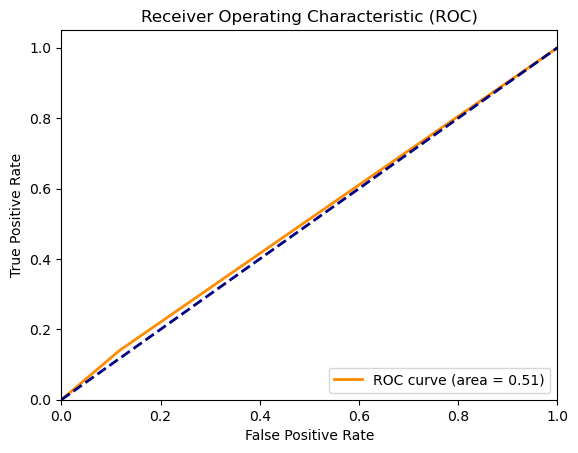

In [93]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_final)

roc_auc = auc(fpr, tpr)

# ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Verifiche

C:\Users\CELESTE\AppData\Local\Temp\ipykernel_14820\2926922838.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\CELESTE\anaconda64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


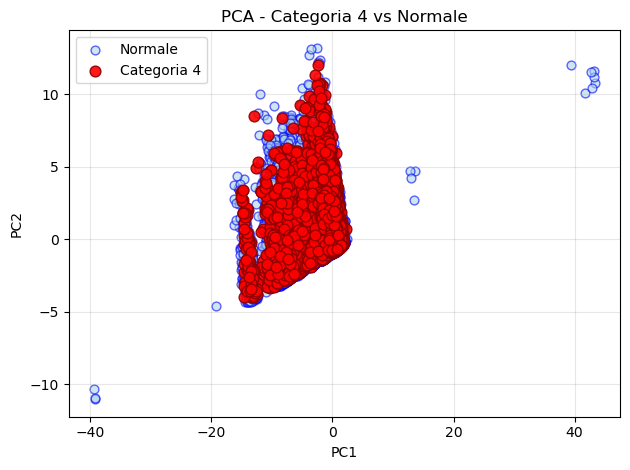

In [98]:
from sklearn.decomposition import PCA

X_train = train_encoded[selected_features]
# PCA su X_train
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train)  # X_train = train_encoded[features]

# Target binario: 1 = categoria 4, 0 = normale
y = y_train

# Scatter plot - Normali in blu
plt.scatter(
    X_2d[y==0, 0], X_2d[y==0, 1],
    facecolors='lightblue',
    edgecolors='blue',
    alpha=0.6,
    s=40,
    label='Normale',
    zorder=1
)

# Scatter plot - Categoria 4 in rosso
plt.scatter(
    X_2d[y==1, 0], X_2d[y==1, 1],
    facecolors='red',
    edgecolors='darkred',
    alpha=0.9,
    s=60,
    label='Categoria 4',
    zorder=5
)

plt.legend()
plt.title('PCA - Categoria 4 vs Normale')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [99]:
# Guarda se le distribuzioni delle feature differiscono tra classe 4 e non-4
print(df.groupby('Severity')[selected_features].mean()) 

# Oppure un test statistico
from scipy.stats import mannwhitneyu
for col in selected_features:
    stat, p = mannwhitneyu(df[df['Severity'] == 4][col], 
        df[df['Severity'] != 4][col])
    print(col, p)

          Distance(mi)  Temperature(F)  Humidity(%)  Pressure(in)  \
Severity                                                            
1             0.108343       72.367608    62.137044     29.228502   
2             0.563271       61.573710    64.666765     29.518593   
3             0.429117       62.172015    65.375992     29.688758   
4             1.511985       58.305800    67.412531     29.394434   

          start_weekday  is_weekend  is_night  is_rush_hour  \
Severity                                                      
1              2.251834    0.067622  0.127450      0.528940   
2              2.550000    0.130654  0.143804      0.358641   
3              2.639522    0.170834  0.136579      0.425324   
4              2.784216    0.195769  0.253610      0.278873   

          bad_weather_night  Traffic_Signal  Junction  Crossing   Station  
Severity                                                                   
1                  0.010659        0.396676  0.048711 

In [100]:
from sklearn.neighbors import NearestNeighbors

# Distanza con knn 
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_train[y_train==0])  # solo normali
distances, _ = nn.kneighbors(X_train[y_train==1])  # distanze delle anomalie
print("Distanza media delle anomalie dai normali:", distances.mean())

# distanza media tra obs normali
distances_normali, _ = nn.kneighbors(X_train[y_train==0])
distanza_media_normali = distances_normali.mean()
print("Distanza media tra normali:", distanza_media_normali)

Distanza media delle anomalie dai normali: 0.29963181513286635
Distanza media tra normali: 0.1431604357777755


AE:
- La separazione esiste ma è distribuita su molte dimensioni
- Il reconstruction error medio su tutte le feature diluiva il segnale
- 0.30 non è abbastanza "lontano" da generare un errore di ricostruzione anomalo

IF:
- qui le anomalie non sono punti isolati ma un gruppo denso. IF fatica a isolare cluster, isola meglio punti singoli lontani.

## CatBoost Classifier for binary target

In [104]:
from sklearn.metrics import roc_auc_score, average_precision_score

selected = selected_features 

y_binary = (df['Severity'] == 4).astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    df[selected], y_binary,
    stratify=y_binary,
    test_size=0.2,
    random_state=42
)

categorical_cols = [c for c in selected if c in cat_features or c in bool_features]

train_pool = Pool(data=X_tr, label=y_tr, cat_features=categorical_cols)
test_pool  = Pool(data=X_te, label=y_te, cat_features=categorical_cols)

model = CatBoostClassifier(
    iterations=1000,          
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',        
    class_weights=[1, y_binary.value_counts()[0]/y_binary.value_counts()[1]],  
    random_seed=42,
    verbose=100
)

# Train
model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50, use_best_model=True)

proba = model.predict_proba(test_pool)[:,1]

roc = roc_auc_score(y_te, proba)
pr_auc = average_precision_score(y_te, proba)

print(f"AUC-ROC: {roc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

0:	test: 0.7609756	best: 0.7609756 (0)	total: 289ms	remaining: 4m 48s
100:	test: 0.7958292	best: 0.7958292 (100)	total: 31.9s	remaining: 4m 44s
200:	test: 0.8009258	best: 0.8009258 (200)	total: 1m 3s	remaining: 4m 14s
300:	test: 0.8037390	best: 0.8037390 (300)	total: 1m 51s	remaining: 4m 19s
400:	test: 0.8071034	best: 0.8071034 (400)	total: 2m 25s	remaining: 3m 37s
500:	test: 0.8089112	best: 0.8089112 (500)	total: 3m 2s	remaining: 3m 1s
600:	test: 0.8101269	best: 0.8101269 (600)	total: 3m 40s	remaining: 2m 26s
700:	test: 0.8108314	best: 0.8108581 (685)	total: 4m 34s	remaining: 1m 56s
800:	test: 0.8116414	best: 0.8116414 (800)	total: 5m 33s	remaining: 1m 22s
900:	test: 0.8121674	best: 0.8121788 (899)	total: 6m 14s	remaining: 41.2s
999:	test: 0.8128189	best: 0.8128189 (999)	total: 7m 3s	remaining: 0us

bestTest = 0.8128189211
bestIteration = 999

AUC-ROC: 0.813
PR-AUC: 0.105


In [105]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_te, proba)

thresholds = np.linspace(0.5, 0.9, 50) 
f1_scores = [f1_score(y_te, (proba>=t).astype(int)) for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
print("Soglia ottimale F1:", best_thresh)

Soglia ottimale F1: 0.7612244897959184


In [106]:
# Apply optimal threshold
y_pred_optimal = (proba >= best_thresh).astype(int)
print(classification_report(y_te, y_pred_optimal, digits=3))

              precision    recall  f1-score   support

           0      0.979     0.955     0.967    194696
           1      0.134     0.257     0.176      5304

    accuracy                          0.936    200000
   macro avg      0.557     0.606     0.572    200000
weighted avg      0.957     0.936     0.946    200000



In [107]:
precision = precision_score(y_te, y_pred_optimal)
recall = recall_score(y_te, y_pred_optimal)
f1 = f1_score(y_te, y_pred_optimal)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1: {f1:.3f}")
print("Confusion Matrix:\n", confusion_matrix(y_te, y_pred_optimal))

Precision: 0.134
Recall: 0.257
F1: 0.176
Confusion Matrix:
 [[185904   8792]
 [  3942   1362]]


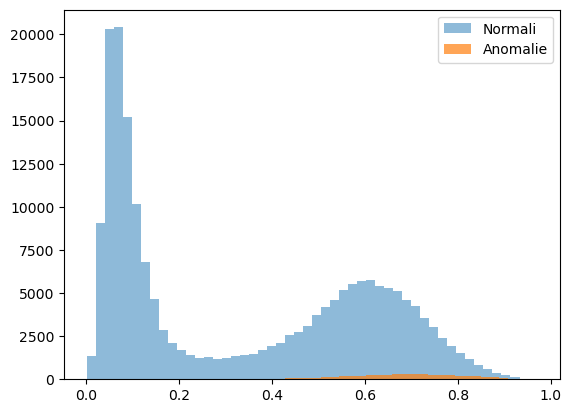

In [108]:
plt.hist(proba[y_te==0], bins=50, alpha=0.5, label="Normali")
plt.hist(proba[y_te==1], bins=50, alpha=0.7, label="Anomalie")
plt.legend()
plt.show()